In [257]:
import numpy as np
import pandas as pd
from numpy import nan
from sklearn.preprocessing import  StandardScaler, OneHotEncoder, MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.datasets import make_classification 
from sklearn.metrics import classification_report, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA, TruncatedSVD
from nltk.stem import SnowballStemmer
from sklearn import linear_model, datasets
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC, LinearSVR
from sklearn.feature_selection import SelectKBest, SelectFpr, chi2, mutual_info_classif, f_classif
from sklearn.linear_model import SGDClassifier
from sklearn.metrics.pairwise import cosine_similarity
from nltk.stem import SnowballStemmer
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
import re
import string
from bs4 import BeautifulSoup
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import confusion_matrix
import numpy as np
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.base import BaseEstimator, TransformerMixin

In [258]:
df = pd.read_csv("winter_project_2026/development.csv")
eva = pd.read_csv("winter_project_2026/evaluation.csv")

In [259]:
mask = ((df['title'].isin(eva['title'])) & (df['article'].isin(eva['article'])) & (df['source'].isin(eva['source'])))
df[mask].groupby('label').count()
#df.drop(df[mask].index, inplace=True) #remove data leakage!!!!!!!?!?!?!??!?!!!

,Id,source,title,article,page_rank,timestamp
label,,,,,,
0,328,328,328,328,328,328
1,163,163,163,163,163,163
2,134,134,134,134,134,134
3,306,306,306,306,306,306
4,53,53,53,53,53,53
5,504,504,504,504,504,504
6,93,93,93,93,93,93


In [260]:
df.drop_duplicates(inplace=True)
df = df.dropna()
test_ids = eva['Id'].copy()
eva['article'].fillna("", inplace=True)

/var/folders/j9/m1q0h7955ls67lg17_lw___80000gn/T/ipykernel_61438/2900358585.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  eva['article'].fillna("", inplace=True)


In [261]:
import re
import string
from bs4 import BeautifulSoup, Comment
import re

def clean_text(text):
    text = text.lower()  # Lowercase
    text = re.sub(r'<[^>]+>', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    text = re.sub(r'\W', ' ', text)  # Remove special characters
    text = BeautifulSoup(text, "html.parser").get_text()  # Remove HTML tags
    return text

def clean_html_professional(html_content):
    if not isinstance(html_content, str):
        return ""
    soup = BeautifulSoup(html_content, "html.parser")
    meta_desc = ""
    meta_tag = soup.find('meta', attrs={'name': 'description'})
    if meta_tag and 'content' in meta_tag.attrs:
        meta_desc = meta_tag['content']
    for tag in soup(['script', 'style', 'noscript', 'iframe', 'svg', 'header', 'footer', 'nav']):
        tag.decompose()
    comments = soup.find_all(string=lambda text: isinstance(text, Comment))
    for c in comments:
        c.extract()
    for img in soup.find_all('img'):
        if 'alt' in img.attrs and img['alt']:
            img.replace_with(f" {img['alt']} ") 
    text = soup.get_text(separator=' ', strip=True)
    final_text = f"{text} {meta_desc}"
    final_text = re.sub(r'\s+', ' ', final_text).strip()
    return final_text

for i, article in zip(df.index, df['article']):
    df.loc[i, 'article'] = clean_html_professional(article)

#for i, article in zip(eva.index, eva['article']):
#    eva.loc[i, 'article'] = clean_html_professional(article)


In [262]:
# unisco le colonne titolo e articolo in una colonna unica raddoppiando l'importanza del titolo
#eva['text'] = eva['source'] + ' ' + eva['source'] + ' ' + eva['title'] + ' ' + eva['title'] + ' ' + eva['title'] + ' ' + eva['article'] + ' ' + eva['article']
#df['text'] = df['source'] + ' ' + df['title'] + ' ' + df['article']
df['text'] = df['source'] + ' ' + df['source'] + ' ' + df['title'] + ' ' + df['title'] + ' ' + df['title'] + ' ' + df['article'] + ' ' + df['article']
df.columns

Index(['Id', 'source', 'title', 'article', 'page_rank', 'timestamp', 'label',
       'text'],
      dtype='object')

In [263]:
import pandas as pd
import numpy as np

def extract_time_features(df):
    dt_series = pd.to_datetime(df['timestamp'], errors='coerce')
    df['day_of_week'] = dt_series.dt.dayofweek.fillna(-1).astype(int)
    hours = dt_series.dt.hour
    conditions = [
        (hours > 5) & (hours <= 14),   # 1: Morning
        (hours > 14) & (hours <= 21),  # 2: Afternoon
        (hours.notna())                # 3: Night
    ]
    choices = [1, 2, 3]
    df['moment_of_day'] = np.select(conditions, choices, default=-1)
    return df

df = extract_time_features(df)
eva = extract_time_features(eva)

In [264]:
df['text_word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['title_word_count'] = df['title'].apply(lambda x: len(str(x).split()))

Calcolo repetition rate...
count    79995.000000
mean         0.600999
std          0.037668
min          0.500000
25%          0.575758
50%          0.595745
75%          0.619355
95%          0.666667
99%          0.735632
max          0.820513
Name: repetition_rate, dtype: float64


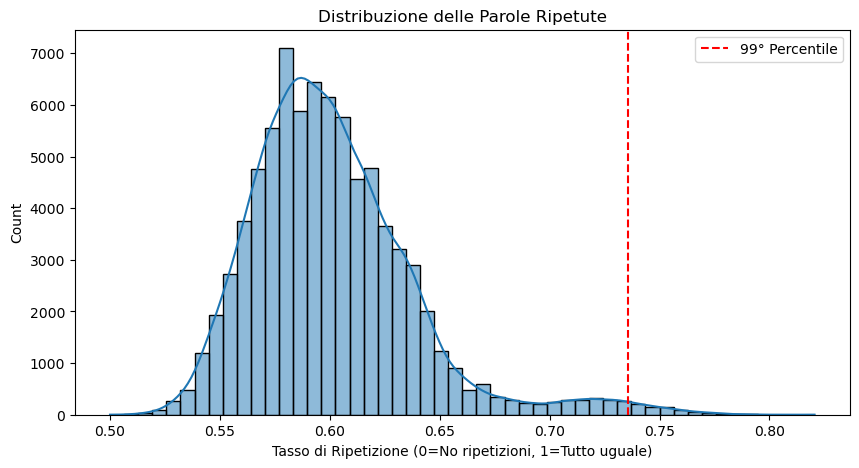

In [265]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def calculate_repetition_rate(text):
    # Protezione contro NaN o float
    text = str(text)
    if not text.strip():
        return 0.0
    
    # Tokenizzazione semplice (split)
    tokens = text.split()
    total_tokens = len(tokens)
    
    if total_tokens == 0:
        return 0.0
    
    # Set rimuove i duplicati
    unique_tokens = len(set(tokens))
    
    # Calcolo: (Totale - Uniche) / Totale
    # Se Totale=100 e Uniche=60, Ripetizione = 40/100 = 0.4
    return 1.0 - (unique_tokens / total_tokens)

# 1. Applicazione veloce
print("Calcolo repetition rate...")
df['repetition_rate'] = df['text'].apply(calculate_repetition_rate)

# 2. Statistiche descrittive
print(df['repetition_rate'].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))

# Visualizzazione della distribuzione
plt.figure(figsize=(10, 5))
sns.histplot(df['repetition_rate'], bins=50, kde=True)
plt.title("Distribuzione delle Parole Ripetute")
plt.xlabel("Tasso di Ripetizione (0=No ripetizioni, 1=Tutto uguale)")
plt.axvline(x=df['repetition_rate'].quantile(0.99), color='r', linestyle='--', label='99° Percentile')
plt.legend()
plt.show()

--- Top 10 Feature più correlate con la Label ---
                                  label
label                          1.000000
page_rank                      0.013223
day_of_week moment_of_day     -0.027255
page_rank day_of_week         -0.033544
day_of_week                   -0.034240
repetition_rate day_of_week   -0.040594
repetition_rate page_rank     -0.047876
page_rank moment_of_day       -0.055071
moment_of_day                 -0.055680
repetition_rate moment_of_day -0.061843

--- Top 10 Feature inversamente correlate (negative) ---
                                    label
repetition_rate page_rank       -0.047876
page_rank moment_of_day         -0.055071
moment_of_day                   -0.055680
repetition_rate moment_of_day   -0.061843
text_word_count day_of_week     -0.067375
text_word_count moment_of_day   -0.070559
text_word_count repetition_rate -0.077526
text_word_count                 -0.079286
text_word_count page_rank       -0.089128
repetition_rate                 

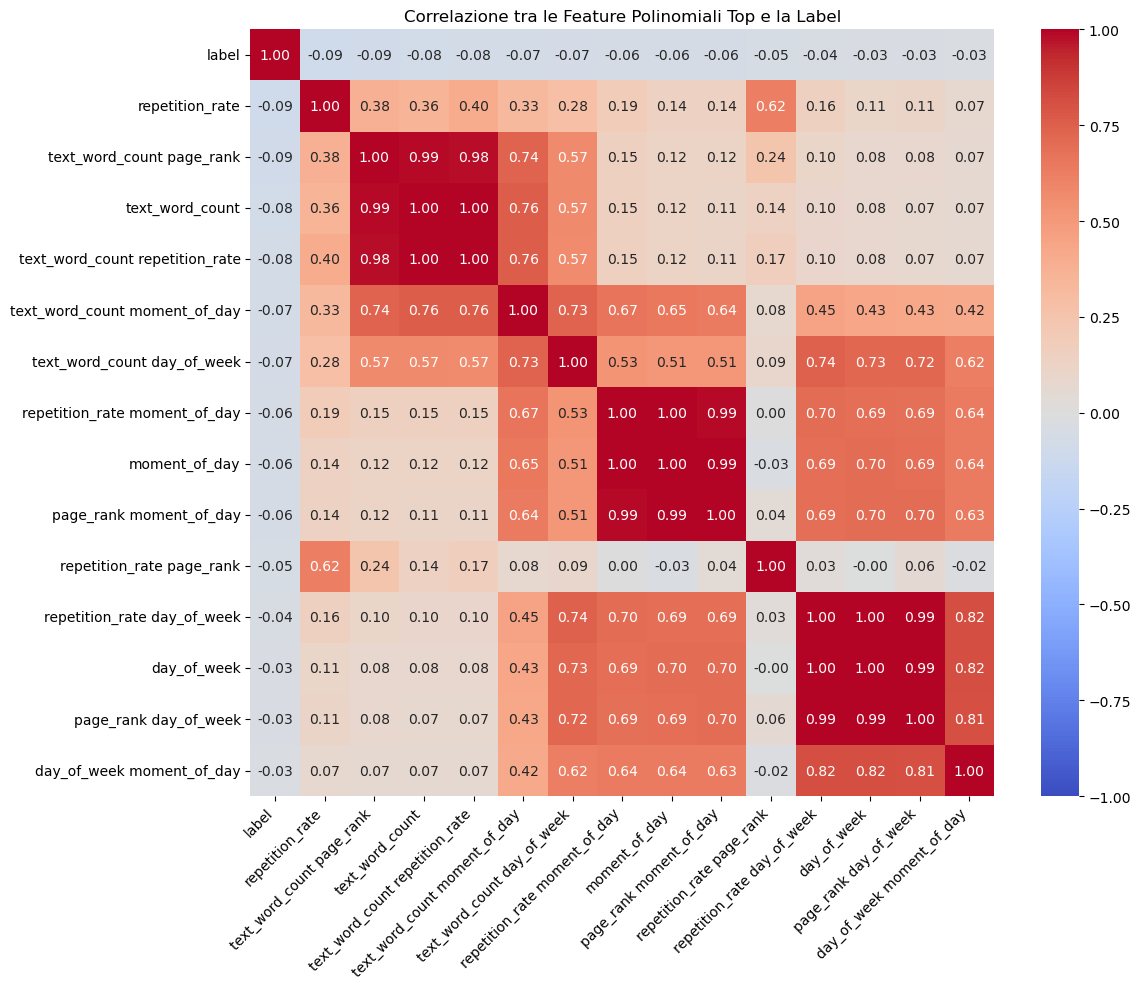

In [266]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

# 1. Seleziona le feature numeriche di base (Escludi la LABEL per ora)
base_cols = ['text_word_count', 'repetition_rate', 'page_rank', 'day_of_week', 'moment_of_day']
X_base = df[base_cols].fillna(0) # Gestione rapida NaN per la demo

# 2. Genera Interaction Features (Grado 2)
# interaction_only=True evita i quadrati (A^2), fa solo incroci (A*B)
# include_bias=False rimuove la colonna di "1"
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X_base)

# 3. Crea un DataFrame con i nomi corretti delle nuove colonne
feature_names = poly.get_feature_names_out(base_cols)
df_poly = pd.DataFrame(X_poly, columns=feature_names, index=df.index)

# 4. Aggiungi la colonna LABEL al nuovo dataframe per vedere le correlazioni con il target
# Nota: Assicurati che 'label' sia nel df originale
df_poly['label'] = df['label']

# 5. Calcola la matrice di correlazione
corr_matrix = df_poly.corr()

# 6. FILTRO INTELLIGENTE:
# Visualizziamo solo le correlazioni con la 'label' per capire quali feature nuove servono
target_corr = corr_matrix[['label']].sort_values(by='label', ascending=False)

print("--- Top 10 Feature più correlate con la Label ---")
print(target_corr.head(10))
print("\n--- Top 10 Feature inversamente correlate (negative) ---")
print(target_corr.tail(10))

# 7. Plot della Heatmap Completa (Magari filtrando le prime 15 feature più forti per leggibilità)
# Prendiamo le 15 colonne che hanno correlazione assoluta più alta con la label
top_cols = target_corr.abs().nlargest(15, 'label').index
plt.figure(figsize=(12, 10))
sns.heatmap(df_poly[top_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlazione tra le Feature Polinomiali Top e la Label")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

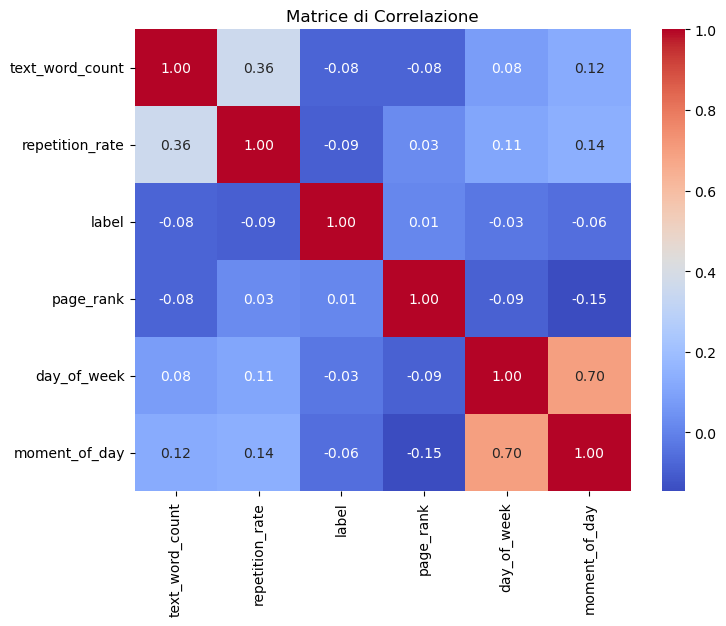

In [267]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcola la matrice su tutte le colonne numeriche
col = list(df.columns)

correlation_matrix = df[['text_word_count', 'repetition_rate', 'label', 'page_rank', 'day_of_week', 'moment_of_day']].corr()

# Visualizza
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice di Correlazione")
plt.show()

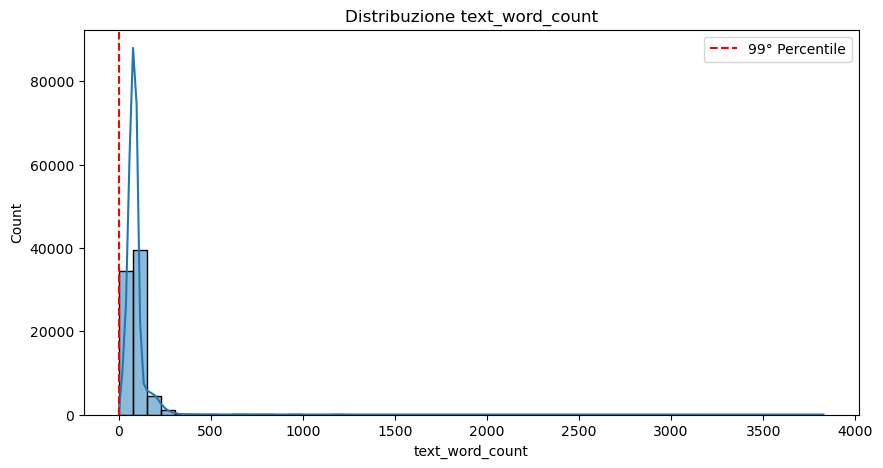

In [268]:
plt.figure(figsize=(10, 5))
sns.histplot(df['text_word_count'], bins=50, kde=True)
plt.title("Distribuzione text_word_count")
plt.axvline(x=df['repetition_rate'].quantile(0.99), color='r', linestyle='--', label='99° Percentile')
plt.legend()
plt.show()

In [269]:
y = df['label']
df.drop('label', inplace=True, axis=1)

In [270]:
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2, random_state=42, stratify=y, shuffle=True)

In [271]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import chi2

def extract_top_features_per_class(X_tfidf, y, feature_names, top_n=20):
    """
    X_tfidf: Matrice sparsa dal TfidfVectorizer (NON SVD!)
    y: Le label di training
    feature_names: Lista delle parole (da vectorizer.get_feature_names_out())
    """
    unique_labels = np.unique(y)
    top_features = {}
    
    print(f"Analisi feature più discriminanti per {len(unique_labels)} classi...")
    
    for label in unique_labels:
        # 1. Binarizza la label: 1 se è la classe corrente, 0 per tutte le altre
        # Questo trasforma il problema in "Questa Classe vs Tutto il Resto"
        y_binary = (y == label).astype(int)
        
        # 2. Calcola Chi-Quadro
        chi2_scores, p_values = chi2(X_tfidf, y_binary)
        
        # 3. Ordina gli indici per score decrescente
        sorted_indices = np.argsort(chi2_scores)[::-1]
        
        # 4. Estrai le parole top
        best_indices = sorted_indices[:top_n]
        best_words = [feature_names[i] for i in best_indices]
        best_scores = chi2_scores[best_indices]
        
        # Salviamo per visualizzazione
        top_features[label] = list(zip(best_words, best_scores))
        
        print(f"\n--- CLASSE {label} TOP WORDS ---")
        print(", ".join([f"{word}" for word in best_words]))
        
    return top_features

# --- ESEMPIO DI UTILIZZO NELLA TUA PIPELINE ---

# 1. Devi fittare SOLO il vectorizer testuale (senza SVD e senza standardizer per ora)
# Assumiamo tu abbia già fatto lo split X_train, y_train sui dati grezzi
temp_vectorizer = TfidfVectorizer(max_features=60000, stop_words='english', min_df=3)
X_train_tfidf = temp_vectorizer.fit_transform(X_train['text']) # Solo colonna testo!

# 2. Estrai i nomi delle feature
vocab = temp_vectorizer.get_feature_names_out()

# 3. Lancia la funzione
top_words_dict = extract_top_features_per_class(X_train_tfidf, y_train, vocab, top_n=1000)

Analisi feature più discriminanti per 7 classi...

--- CLASSE 0 TOP WORDS ---
afp, ap, topix, bbc, minister, net, iraq, president, yahoo, prime, presidential, killed, police, darfur, sudan, cnn, democratic, peace, afghanistan, microsoft, iran, election, eu, nuclear, republican, leader, british, blair, pakistan, party, military, french, israeli, bomb, troops, russia, israel, cnet, csmonitor, government, game, motley, iraqi, hopeful, bush, elections, foreign, soldiers, talks, rebels, gaza, rebel, kosovo, militants, palestinian, killing, press, war, clinton, german, afghan, army, terror, nato, leaders, campaign, rodham, cqpolitics, opposition, baghdad, obama, hostage, european, political, lebanon, visit, vote, sen, software, nations, google, apple, com, envoy, korea, muslim, violence, corp, pm, aid, said, ips, serbia, african, britain, turkey, poland, company, candidate, romney, country, pope, forbes, forces, region, sri, season, parliament, islamic, france, poll, italy, indonesia, al, ke

In [272]:
# Creiamo il vocabolario "Smart"
smart_vocabulary = set()
for label in top_words_dict:
    words = [x[0] for x in top_words_dict[label]]
    smart_vocabulary.update(words)

print(f"Nuovo vocabolario ridotto: {len(smart_vocabulary)} parole")

# Nuovo Vectorizer chirurgico
smart_vectorizer = TfidfVectorizer(vocabulary=smart_vocabulary)
# Ora il tuo X avrà poche feature ma tutte molto significative

Nuovo vocabolario ridotto: 5716 parole


In [273]:
encoder = OneHotEncoder(min_frequency=70, handle_unknown='ignore')
standardizer = StandardScaler()

vectorizer_svd = Pipeline([( 'vect', TfidfVectorizer(
        max_features=30000,
        stop_words='english',
        ngram_range=(1, 2),
        min_df=3)),
        ('svd', TruncatedSVD(
            n_components=1000, 
            algorithm='randomized'))
        ])

vectorizer = TfidfVectorizer(
        max_features=60000,
        stop_words='english',
        ngram_range=(1, 2),
        min_df=3)

vectorizer2 = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3,5),
    min_df=5,
    max_features=30000
)

preprocessor = ColumnTransformer(transformers=[
    ('text_char',vectorizer2, 'text'),
    ('text_svd',smart_vectorizer, 'text'),
], remainder='drop', n_jobs=-1)
    #('numerical', standardizer, ['text_word_count', 'repetition_rate', 'day_of_week', 'moment_of_day'])
    #('text',vectorizer, 'text'),


In [274]:
class DiscriminativeDistanceFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, beta=0.75):
        self.beta = beta
        self.centroids_ = None

    def fit(self, X, y):
        # 1. Calcolo i centroidi classici (Media)
        self.classes_ = np.unique(y)
        original_centroids = []
        for c in self.classes_:
            # Prendo tutti i documenti di quella classe e faccio la media
            cluster_mean = X[y == c].mean(axis=0)
            # Se X è sparsa, mean restituisce np.matrix, convertiamo in array
            original_centroids.append(np.asarray(cluster_mean).flatten())
        
        original_centroids = np.array(original_centroids)
        
        # 2. Applico la tua idea: Sposto il centroide lontano dagli altri
        self.discriminative_centroids_ = []
        for i, c_vec in enumerate(original_centroids):
            # Calcolo la media di TUTTI gli altri centroidi tranne questo
            other_centroids = np.delete(original_centroids, i, axis=0)
            avg_others = other_centroids.mean(axis=0)
            
            # Formula di Rocchio semplificata:
            # Nuovo_Centro = Centro_Mio - (Beta * Centro_Nemici)
            new_c = c_vec - (self.beta * avg_others)
            self.discriminative_centroids_.append(new_c)
            
        self.discriminative_centroids_ = np.array(self.discriminative_centroids_)
        return self

    def transform(self, X):
        # 3. Calcolo la distanza di ogni documento dai nuovi centroidi discriminanti
        # Restituisce una matrice (n_samples, n_classes)
        return euclidean_distances(X, self.discriminative_centroids_)

In [275]:
X_train_final = preprocessor.fit_transform(X_train)
X_test_final = preprocessor.transform(X_test)

In [279]:
svm_clf = SGDClassifier(
    loss='log_loss', 
    penalty='l2',
    alpha=1e-5,
    max_iter=2000,
    tol=1e-6,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

clf = LogisticRegression(
    C=1,                       
    solver='saga',        
    penalty='elasticnet',           
    max_iter=1500,              
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    multi_class='multinomial',
    l1_ratio=0.5
)

voting_clf = VotingClassifier(
    estimators=[ 
        ('svm', svm_clf), 
        ('lr', clf)
    ], n_jobs=-1,
    voting='soft'
)

voting_clf.fit(X_train_final, y_train)
y_pred = voting_clf.predict(X_test_final)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

print(f1_score(y_test, y_pred, average='macro'))

/opt/homebrew/Caskroom/miniconda/base/envs/dsml/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


KeyboardInterrupt: 

In [277]:
# --- UTILIZZO ---
# Nota: Usa X_train_final (o la versione ridotta SVD), non il testo grezzo
# beta=0.5 significa "allontanati moderatamente dagli altri"
#discriminative_transformer = DiscriminativeDistanceFeatures(beta=0.6)
#
## Fit sui dati di training usando le LABEL (y_train)
#discriminative_transformer.fit(X_train_final, y_train)
#
## Generiamo le nuove feature
#X_train_dist = discriminative_transformer.transform(X_train_final)
#X_test_dist = discriminative_transformer.transform(X_test_final)
#
#
#
#X_train_dist = np.asarray(X_train_dist, dtype=np.float64)
#X_test_dist = np.asarray(X_test_dist, dtype=np.float64)
#
## 2. Convertiamo le distanze in matrici sparse CSR
#X_train_dist_sparse = sp.csr_matrix(X_train_dist)
#X_test_dist_sparse = sp.csr_matrix(X_test_dist)
#
## 3. Ora l'unione sarà fluida perché i tipi coincidono
#print("Eseguo lo stacking delle matrici...")
#X_train_augmented = sp.hstack([X_train_final, X_train_dist_sparse])
#X_test_augmented = sp.hstack([X_test_final, X_test_dist_sparse])
#print(X_train_dist.shape)
#print(X_train_final.shape)
#print(X_test_dist.shape)
#print(X_test_final.shape)
#
## Concateniamo come prima
#import scipy.sparse as sp
#X_train_augmented = sp.hstack([X_train_final, X_train_dist])
#X_test_augmented = sp.hstack([X_test_final, X_test_dist])

In [278]:
#submission = pd.DataFrame({
#    'Id': test_ids,    # Usiamo gli ID salvati all'inizio
#    'Predicted': y_pred # O 'label' o 'Category' a seconda delle regole della gara
#})
#
#submission.to_csv('submission_html_pp.csv', index=False)
#print("Fatto! File pronto.")